In [1]:
import pandas as pd

In [2]:
import datetime as dt
import yfinance as yf

In [3]:
start=dt.datetime(2020,1,1)
end=dt.datetime(2023,12,31)
stk_data=yf.download("RELIANCE.NS",start="2020-1-1",end="2023-12-31")

[*********************100%***********************]  1 of 1 completed


In [4]:
stk_data.columns=stk_data.columns.get_level_values(0)

In [5]:
stk_data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')

In [6]:
stk_data=stk_data[["Open","High","Low","Close"]]

In [7]:
stk_data

Price,Open,High,Low,Close
Date,,,,
2020-01-01,675.956609,680.008790,670.390471,672.216125
2020-01-02,673.284861,686.176147,673.284861,683.660217
2020-01-03,682.636001,686.487835,678.183067,684.484009
2020-01-06,676.847198,680.364982,667.050708,668.609253
2020-01-07,676.401934,683.304036,673.952826,678.895630
...,...,...,...,...
2023-12-22,1264.550536,1275.073539,1258.646635,1267.243042
2023-12-26,1268.700379,1280.532666,1266.081931,1273.665527
2023-12-27,1275.617031,1284.460338,1271.220103,1278.013184


In [8]:
stk_data.to_csv("RELIANCE.NS.csv")

In [9]:
column="Close"

In [10]:
from sklearn.preprocessing import MinMaxScaler
ms=MinMaxScaler()
data1=ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (992, 1)


In [11]:
training_size=round(len(data1)*0.95)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

942
X_train length: (942, 1)
X_test length: (50, 1)
y_train length: (942, 1)
y_test length: (50, 1)


In [12]:
import warnings
warnings.filterwarnings("ignore")

In [13]:
from sklearn.metrics import mean_squared_error
trends=['n','t','c','ct']
orders=[(0,0,1),(0,0,2)]
from statsmodels.tsa.arima.model import ARIMA
for td in trends:
    model=ARIMA(X_train,order=(0,0,10),trend=td)
    model_fit=model.fit()
    y_pred=model_fit.predict(len(X_train),len(data1)-1)

    from sklearn.metrics import r2_score
    mse=mean_squared_error(y_test,y_pred)
    from stockFunctions import rmsemape
    print("Trend={}:".format(td))
    rmsemape(y_test,y_pred)
    print("************")

Trend=n:
RMSE-Testset: 0.8379316974881176
MAPE-Testset: 0.9132399719023523
************


C:\Anaconda3\envs\aitsa\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Trend=t:
RMSE-Testset: 0.3041815148541155
MAPE-Testset: 0.3434385502814134
************


C:\Anaconda3\envs\aitsa\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Trend=c:
RMSE-Testset: 0.19962176520185268
MAPE-Testset: 0.2083656960370772
************
Trend=ct:
RMSE-Testset: 0.12391577562185883
MAPE-Testset: 0.1342024470734775
************


In [14]:
len(y_pred)

50

In [15]:
td="ct"
model = ARIMA(X_train, order=(0,0,30),trend=td)
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(len(X_train), len(data1)-1)
#print(y_pred)
from sklearn.metrics import r2_score
mse=mean_squared_error(y_test,y_pred)
from stockFunctions import rmsemape
print("Trend={}".format(td))
rmsemape(y_test,y_pred)
print("************")

C:\Anaconda3\envs\aitsa\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Trend=ct
RMSE-Testset: 0.08087625081430087
MAPE-Testset: 0.08523930826668766
************


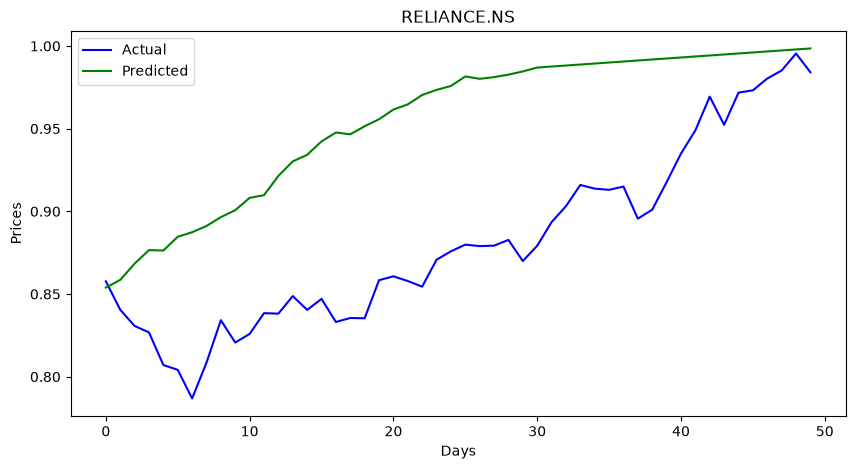

In [16]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","RELIANCE.NS","Days","Prices")

In [17]:
len(data1)

992

In [18]:
#inversing original data for Actual price

from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])
actual_stock_price_test_ori=ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [19]:
actual_stock_price_test_oriA

,Close
0,1163.592896
1,1148.154175
2,1139.335449
3,1135.852539
4,1118.116333
5,1115.522705
6,1099.984863
7,1119.400879
8,1142.472656
9,1130.319214


In [20]:
#inversing original data for predicted price

from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_pred,[column])
predicted_stock_price_test_ori=ms.inverse_transform(aTestNormTable)
predicted_stock_price_test_orip=conversionSingle(predicted_stock_price_test_ori,[column])

In [21]:
predicted_stock_price_test_orip

,Close
0,1160.179157
1,1164.341749
2,1173.163409
3,1180.496509
4,1180.295947
5,1187.758002
6,1190.21344
7,1193.620919
8,1198.419092
9,1202.184014


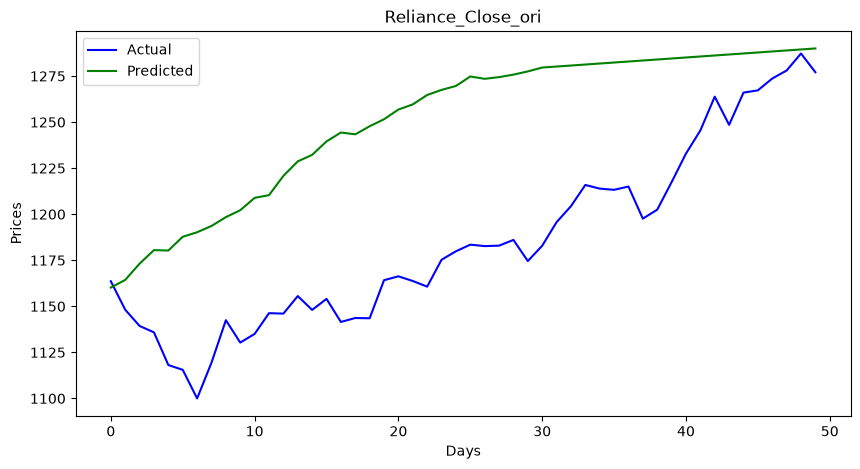

In [22]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_orip,"Actual","Predicted","Reliance_Close_ori","Days","Prices")

In [23]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_orip)

RMSE-Testset: 72.59953603171763
MAPE-Testset: 0.0565444236097528


In [24]:
forecast=model_fit.predict(len(data1),len(data1)+4)

In [25]:
forecast

array([0.99912461, 0.99973245, 1.00034029, 1.00094813, 1.00155596])

In [26]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [27]:
forecast_stock_price_test_oriF

,Closefore
0,1290.538535
1,1291.084169
2,1291.629803
3,1292.175437
4,1292.721071


In [28]:
forecast_stock_price_test_oriF.to_csv("CloseMA.csv",index=False)